# Tofwerk FIB-SIMS Reader and Signal Demo

Demonstrates the `rsciio` Tofwerk HDF5 reader and the `exspy.FIBSIMSSpectrum` signal class.

Since FIB-SIMS datasets are often quite large (the example here is about 18GB uncompressed),
it is recommended to use lazy processing throughout.

It assumes some knowledge on how to use HyperSpy, like loading datasets and how the basic signals work.

This notebook requires **HyperSpy 2.0.0** or later. In addition **eXSpy**, which has the spectral data analysis parts of HyperSpy: https://hyperspy.org/exspy/ and **RosettaSciIO 0.14.0** or later, which added the Tofwerk data reader.

The notebook requires downloading two large data files (4.4 GB total):

- **pfib_1301x128x128_AlTiPt_raw.h5** — a raw TOF-SIMS data file as produced by TofDAQ, containing the full EventList (ragged TDC timestamp arrays) and FIB SE images. No pre-integrated peak data.
- **pfib_1301x128x128_AlTiPt.h5** — the same data as the "raw" file, but pre-processed by the TofDAQ software, which adds a PeakData group with 216 nominal integer-mass peaks and one user-selected peak (¹⁹⁴Pt at 193.95 Da) pre-integrated by the TofDAQ software.

## Author

28/4/2026 Josh Taillon ([https://datasophos.co](datasophos))

## Table of contents

1. <a href='#1-Setup'> Setup</a>
2. <a href='#2-Checking-available-signals'> Checking available signals</a>
3. <a href='#3-Opening-datasets-with-the-signal-parameter'> Opening raw and preprocessed datasets with the `signal` parameter</a><br/>
    a. <a href='#3.1-Basic-eXSpy-processing-of-FIB-SIMS-data'> Basic eXSpy processing of FIB-SIMS data</a> 
5. <a href='#4-Metadata'> FIB-SIMS signal metadata</a>
6. <a href='#5-Peak-table-&-reintegration'> Peak table operations and reintegration</a><br/>
    a. <a href='#5.1-Modifying-integration-windows'> Modifying integration windows</a>
7. <a href='#6-Example-Elemental-Analysis'> Example elemental analysis</a>

**Sections:**
1. Setup
2. Checking available signals
3. Opening raw and preprocessed datasets with the `signal` parameter
4. FIB-SIMS signal metadata
5. Peak table operations and reintegration
6. Example elemental analyses

---
## 1 Setup

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import time

import hyperspy.api as hs
import exspy
import rsciio
from rsciio.tofwerk import available_signals

for lib, ver in [('hyperspy', hs.__version__), ('exspy', exspy.__version__), ('rsciio', rsciio.__version__)]:
    print(f'{lib:10s} {ver}')

In [3]:
# download example data (may take a while; each file is 2.2GB):
import pooch

PREPROCESSED = pooch.retrieve(
    url="https://zenodo.org/records/19873993/files/pfib_1301x128x128_AlTiPt.h5",
    known_hash="md5:a88c36648b9c3134a03c7015f6f2b91d",
    progressbar=True
)

RAW = pooch.retrieve(
    url="https://zenodo.org/records/19873993/files/pfib_1301x128x128_AlTiPt_raw.h5",
    known_hash="md5:9ccab702ec44272056dd13c9d191c61c",
    progressbar=True
)

---
## 2 Checking available signals


In [4]:
print("PREPROCESSED:", available_signals(PREPROCESSED))
print("RAW:", available_signals(RAW))

PREPROCESSED: ['sum_spectrum', 'nominal_peak_data', 'additional_peak_data', 'event_list', 'fib_images']
RAW: ['sum_spectrum', 'nominal_peak_data', 'event_list', 'fib_images']


---
## 3 Opening datasets with the `signal` parameter

Pass `signal` (string or list) to control which signals are loaded.

| Value | Returns | Notes |
|---|---|---|
| `"sum_spectrum"` *(default)* | 1-D cumulative spectrum | Always fast |
| `"nominal_peak_data"` | 4-D `(depth, y, x \| m/z)` | Opened: reads peaks with a label of "nominal" from `PeakData`; Raw: reconstructs from EventList (can take some time) |
| `"additional_peak_data"` | 4-D `(depth, y, x \| m/z)` | Opened: reads peaks with lables other than "nominal" from `PeakData`; Raw: reconstructs from EventList (can take some time) |
| `"event_list"` | Ragged `(depth, y, x)` of uint16 TDC timestamps | Ragged signal cannot be plotted |
| `"all"` | All available signals | 2–3 depending on file |
| `"fib_images"` | FIB SE image data | |
| `["sum_spectrum", "peak_data"]` | Specific subset | One entry per requested signal |

When `hs.load` receives a single-signal result it **unwraps** the list — no `[0]` indexing needed.
Multiple signals are returned as a list as normal.

#### A "raw" dataset

Demonstrates interacting with a "raw" dataset, meaning it has not had SIMS peak data collected, and is exactly as the original file is produced by the TofDAQ software

default          -> 1 signal : <LazyFIBSIMSSpectrum, title: pfib_1301x128x128_AlTiPt_raw (sum spectrum), dimensions: (|11958)>


  0%|          | 0/2 [00:00<?, ?it/s]

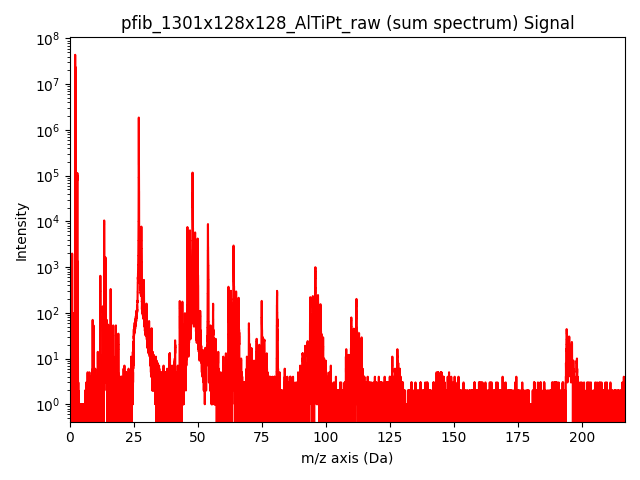

In [3]:
# Single-signal results are unwrapped by hs.load, and the default is the total
# mass sum spectrum across the entire dataset
s = hs.load(RAW, file_format='Tofwerk', lazy=True)
print(f'default          -> 1 signal : {s}')
s.plot()

In [4]:
# You can also load the "FullSpectra/EventList" dataset, which is the raw
# unprocessed ragged object array (depth, y, x) of uint16 TDC timestamps, 
# one variable-length array per pixel. Because it is ragged, this signal cannot be
# plotted.
s = hs.load(RAW, file_format='Tofwerk', signal='event_list', lazy=True)
print(f"Dataset is {s.data.nbytes / 1e9:.2f} GB")
try:
    s.plot()
except RuntimeError as e:
    print(e)

Dataset is 0.17 GB
Plotting ragged signal is not supported.


In [5]:
# FIB images are also available as a depth stack
# sometimes the software truncates images, and the reader will warn you if this
# was detected and any images were omitted as a result
ims = hs.load(RAW, file_format="Tofwerk", signal='fib_images', lazy=True)
print(f"Dataset is {ims.data.nbytes / 1e9:.2f} GB")
ims.axes_manager

WARNING | RosettaSciIO | FIBImages: 1 image(s) skipped — shape differs from dominant (256, 256): Image1300 (254, 256) (rsciio.tofwerk._api:1410)
Dataset is 0.68 GB


Navigation axis name,size,index,offset,scale,units
depth,1300,0,0.0,1.0,slice
Signal axis name,size,,offset,scale,units
x,256,,0.0,0.078125,µm
y,256,,0.0,0.078125,µm


In [6]:
# If you request nominal peak data from a "raw" dataset, it will be computed from
# the EventList data on-demand using the default PeakTable present in the dataset
# (takes about a minute on an M4 Macbook Air for the given dataset)
# this requires setting lazy=False to eagerly load the EventData. Using lazy=True
# will raise a runtime error
s = hs.load(RAW, file_format='Tofwerk', signal='nominal_peak_data', lazy=False)
print(f'peak_data        -> 1 signal : {s}')
print(f"Dataset is {s.data.nbytes / 1e9:.2f} GB")
s.axes_manager

Reconstructing peak data:   0%|          | 0/1301 [00:00<?, ? slices/s]

peak_data        -> 1 signal : <FIBSIMSSpectrum, title: pfib_1301x128x128_AlTiPt_raw (nominal peak data), dimensions: (128, 128, 1301|216)>
Dataset is 9.21 GB


Navigation axis name,size,index,offset,scale,units
x,128,0,0.0,0.15625,µm
y,128,0,0.0,0.15625,µm
depth,1301,0,0.0,1.0,slice
Signal axis name,size,,offset,scale,units
m/z,216,,non-uniform axis,non-uniform axis,Da


In [7]:
s.plot(norm="linear")

In [8]:
# If you request additional peak data from a dataset that does not have additional, 
# peaks defined in the PeakTable (such as the raw example in this notebook), you will
# receive an error informing you as such
try: 
    s = hs.load(RAW, file_format='Tofwerk', signal='additional_peak_data', lazy=False)
except ValueError as e:
    print("ERROR:", e)

ERROR | Hyperspy | If this file format is supported, please report this error to the RosettaSciIO developers at https://github.com/hyperspy/rosettasciio/issues (hyperspy.io:818)
ERROR: signal='additional_peak_data' requested but not available (no additional/custom peaks in PeakTable, or no PeakData/PeakData and no EventList+PeakTable).


#### A "pre-processed" dataset

Demonstrates interacting with a "pre-processed" dataset, meaning it has had SIMS peak data collected, and some basic processing done by the TofDAQ software. Namely, the `PeakData` dataset is present in the file on disk, and it has an additional custom peak defined for Pt at 194 Da

default          -> 1 signal : <LazyFIBSIMSSpectrum, title: pfib_1301x128x128_AlTiPt (sum spectrum), dimensions: (|11958)>


  0%|          | 0/2 [00:00<?, ?it/s]

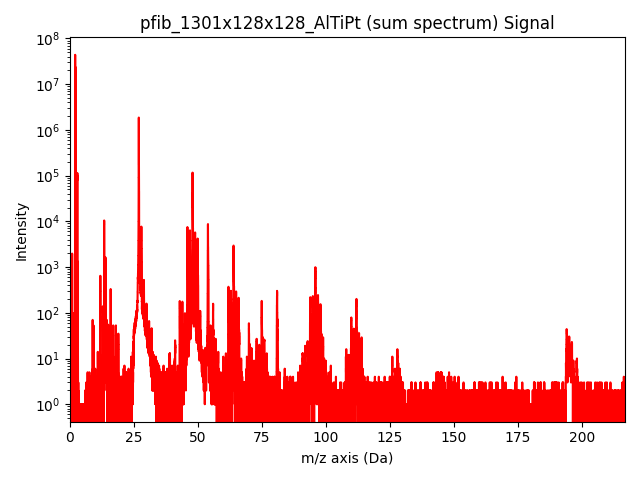

In [9]:
# Single-signal results are unwrapped from a list by hs.load
s = hs.load(PREPROCESSED, file_format='Tofwerk', lazy=True)
print(f'default          -> 1 signal : {s}')
s.plot()

In [10]:
# event list data is still present in a pre-processed dataset
s = hs.load(PREPROCESSED, file_format='Tofwerk', signal='event_list', lazy=True)
print(f"Dataset is {s.data.nbytes / 1e9:.2f} GB")
try:
    s.plot()
except RuntimeError as e:
    print(e)

Dataset is 0.17 GB
Plotting ragged signal is not supported.


In [11]:
# loading peak_data as a lazy signal should be nearly instant for a pre-processed dataset
peak_data = hs.load(PREPROCESSED, file_format='Tofwerk', signal='nominal_peak_data', lazy=True)
print(f'peak_data        -> 1 signal : {s}')
print(f"Dataset is {peak_data.data.nbytes / 1e9:.2f} GB")
peak_data.axes_manager

peak_data        -> 1 signal : <LazySignal, title: pfib_1301x128x128_AlTiPt (event list), dimensions: (128, 128, 1301|ragged)>
Dataset is 18.42 GB


Navigation axis name,size,index,offset,scale,units
x,128,0,0.0,0.15625,µm
y,128,0,0.0,0.15625,µm
depth,1301,0,0.0,1.0,slice
Signal axis name,size,,offset,scale,units
m/z,216,,non-uniform axis,non-uniform axis,Da


In [12]:
peak_data.plot()

  0%|          | 0/175 [00:00<?, ?it/s]

In [13]:
# you can also separately request "additional_peak_data" from the dataset:
additional_peak_data = hs.load(PREPROCESSED, file_format='Tofwerk', signal='additional_peak_data', lazy=True)
print(f'peak_data        -> 1 signal : {s}')
print(f"Dataset is {additional_peak_data.data.nbytes / 1e9:.2f} GB")
additional_peak_data.axes_manager

peak_data        -> 1 signal : <LazySignal, title: pfib_1301x128x128_AlTiPt (event list), dimensions: (128, 128, 1301|ragged)>
Dataset is 0.09 GB


Navigation axis name,size,index,offset,scale,units
x,128,0,0.0,0.15625,µm
y,128,0,0.0,0.15625,µm
depth,1301,0,0.0,1.0,slice
Signal axis name,size,,offset,scale,units
m/z,1,,non-uniform axis,non-uniform axis,Da


  0%|          | 0/88 [00:00<?, ?it/s]

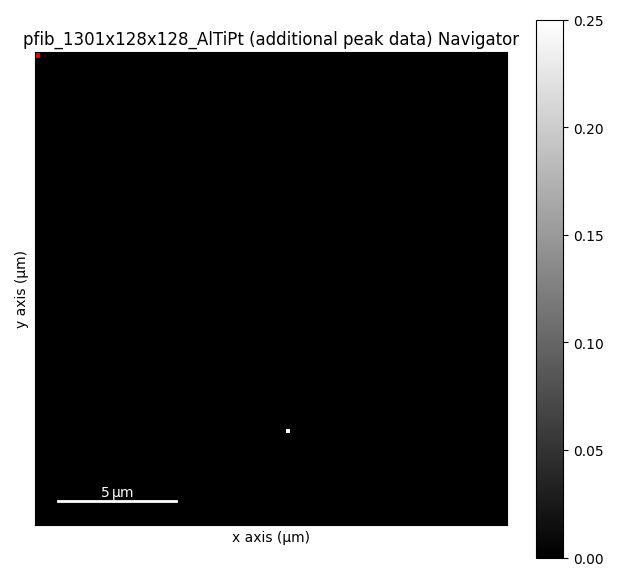

In [14]:
# this example dataset has just one additional peak defined (signal axis length is 1), 
# so you will get a stack of images, rather than a 4D-stack
additional_peak_data.plot()

In [15]:
# FIB images are also available as a depth stack
# sometimes the software truncates images, and the reader will warn you if this was detected
ims = hs.load(PREPROCESSED, file_format="Tofwerk", signal='fib_images', lazy=True)
print(f"Dataset is {ims.data.nbytes / 1e9:.2f} GB")
ims.axes_manager

WARNING | RosettaSciIO | FIBImages: 1 image(s) skipped — shape differs from dominant (256, 256): Image1300 (254, 256) (rsciio.tofwerk._api:1410)
Dataset is 0.68 GB


Navigation axis name,size,index,offset,scale,units
depth,1300,0,0.0,1.0,slice
Signal axis name,size,,offset,scale,units
x,256,,0.0,0.078125,µm
y,256,,0.0,0.078125,µm


In [16]:
ims.plot()

  0%|          | 0/2601 [00:00<?, ?it/s]

In [17]:
# requesting all available signals or multiple signals returns a list of signals
for sig in hs.load(PREPROCESSED, file_format='Tofwerk', signal='all', lazy=True):
    print(sig)

WARNING | RosettaSciIO | FIBImages: 1 image(s) skipped — shape differs from dominant (256, 256): Image1300 (254, 256) (rsciio.tofwerk._api:1410)
<LazyFIBSIMSSpectrum, title: pfib_1301x128x128_AlTiPt (sum spectrum), dimensions: (|11958)>
<LazyFIBSIMSSpectrum, title: pfib_1301x128x128_AlTiPt (nominal peak data), dimensions: (128, 128, 1301|216)>
<LazyFIBSIMSSpectrum, title: pfib_1301x128x128_AlTiPt (additional peak data), dimensions: (128, 128, 1301|1)>
<LazySignal, title: pfib_1301x128x128_AlTiPt (event list), dimensions: (128, 128, 1301|ragged)>
<LazySignal2D, title: pfib_1301x128x128_AlTiPt (FIB SE images), dimensions: (1300|256, 256)>


In [18]:
# Trying to open an invalid signal from the data value raises ValueError immediately, before any data is read
try:
    hs.load(PREPROCESSED, file_format='Tofwerk', signal='nonsense')
except ValueError as e:
    print(e)

ERROR | Hyperspy | If this file format is supported, please report this error to the RosettaSciIO developers at https://github.com/hyperspy/rosettasciio/issues (hyperspy.io:818)
Invalid signal value(s) in 'nonsense'. Must be one or more of ['sum_spectrum', 'nominal_peak_data', 'additional_peak_data', 'event_list', 'fib_images', 'all'].


## 3.1 Basic eXSpy processing of FIB-SIMS data

The FIB-SIMS data type has a few basic methods for working with ToF-SIMS data.

In [19]:
[sum_spec, peak_data, event_list] = hs.load(PREPROCESSED, file_format='Tofwerk', signal=['sum_spectrum', 'nominal_peak_data', 'event_list'], lazy=True)
peak_data

<LazyFIBSIMSSpectrum, title: pfib_1301x128x128_AlTiPt (nominal peak data), dimensions: (128, 128, 1301|216)>

In [20]:
event_list

<LazySignal, title: pfib_1301x128x128_AlTiPt (event list), dimensions: (128, 128, 1301|ragged)>

### Total Ion Count maps

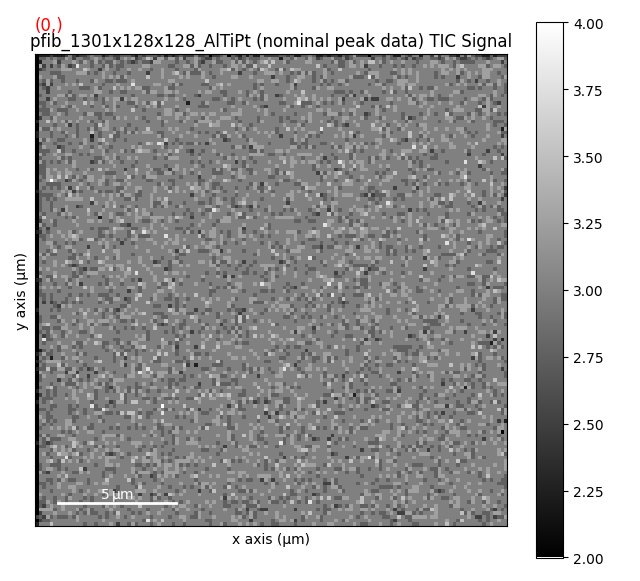

In [21]:
# get_tic() sums the m/z signal axis → Signal2D (depth | y, x) into a Total Ion Count map
# .plot() gives an interactive depth-slice navigator automatically
tic = peak_data.get_tic()
tic.plot(navigator='slider')  # use `navigator='slider'` to avoid calculating sum for navigator

### Normalized Total Ion Count

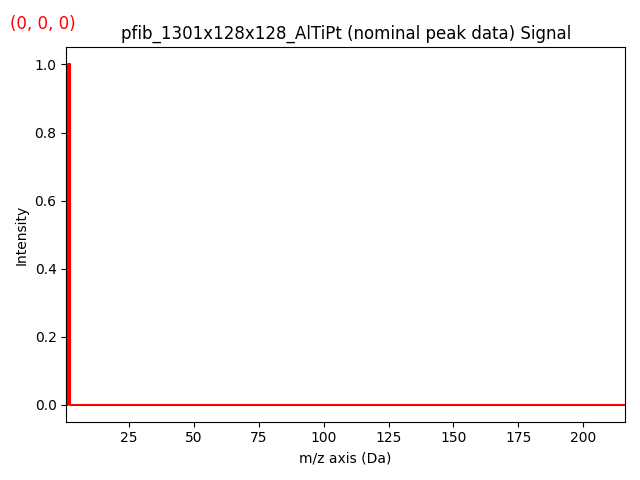

In [22]:
# Normalised TIC: each pixel spectrum divided by its TIC
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    s_norm = peak_data.normalize_tic()
s_norm.plot(navigator='slider', norm="linear")

### Integrated peak maps

Selected peaks: [ 27.  48. 194.] Da  (requested: [27, 48, 194] Da)


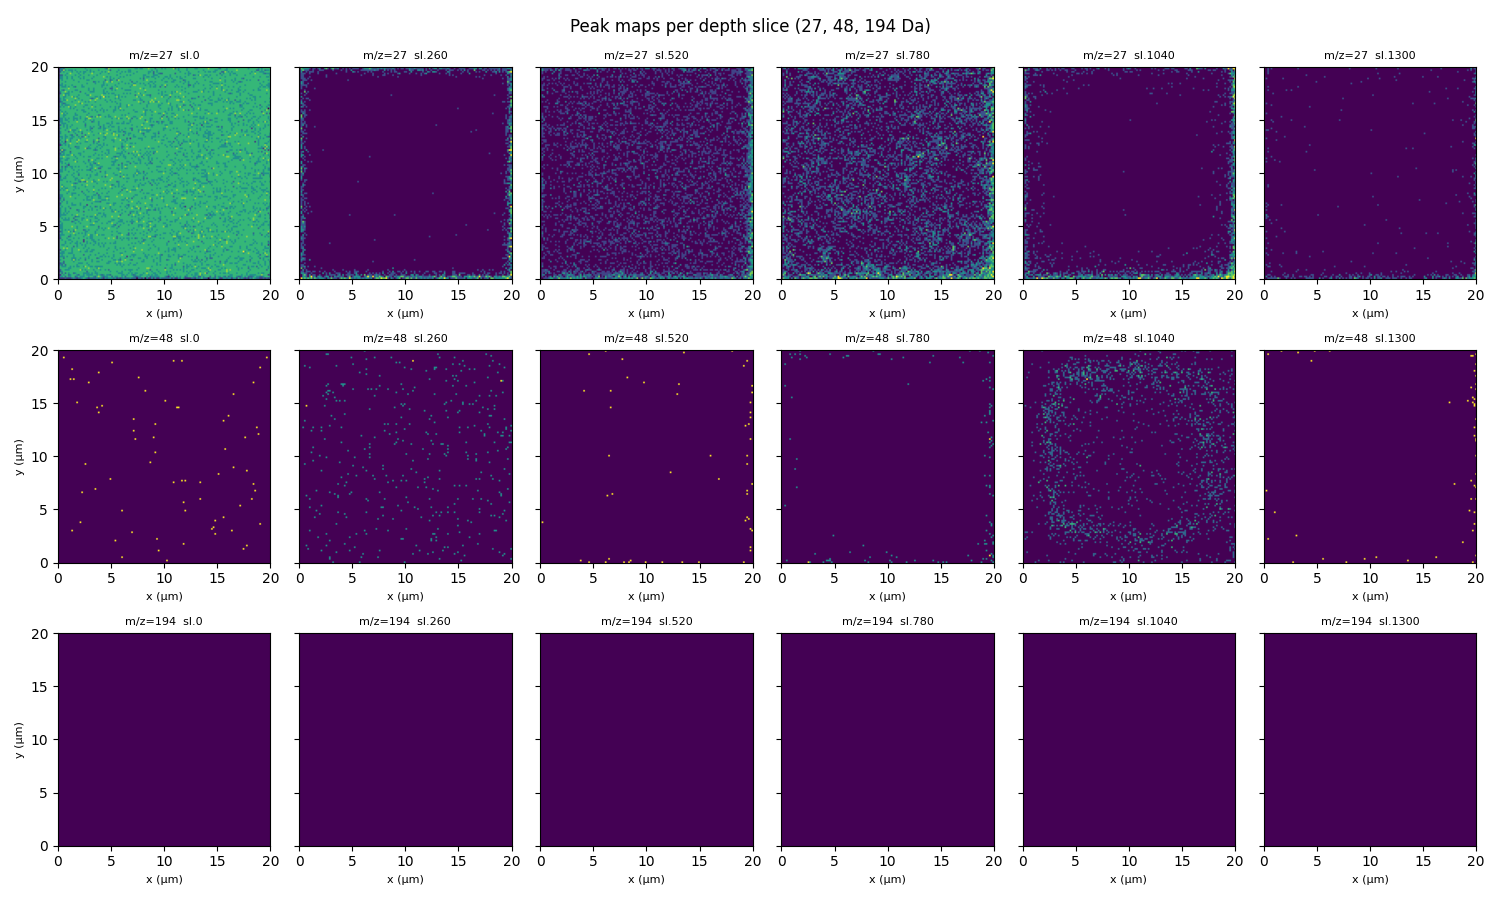

In [23]:
# Plot spatial ion maps for three selected m/z peaks (27, 48, 194 Da) across
# 6 evenly-spaced depth slices. Each row corresponds to one peak; each column
# to one depth slice. Peak indices are found by nearest-neighbour match on the
# m/z axis, so the actual matched mass is printed for verification.
# these peaks correspond to Al+, Ti+, Pt+

# Spatial-plot setup
n_slices  = 6
slice_idx = np.linspace(0, peak_data.data.shape[0] - 1, n_slices, dtype=int)
px  = sum_spec.metadata.Acquisition_instrument.FIB_SIMS.FIB.pixel_size_um
ext = [0, peak_data.data.shape[2] * px, 0, peak_data.data.shape[1] * px]   # µm extent

# Select specific peaks by nearest m/z match
target_masses = [27, 48, 194]  # Da
mz_axis = peak_data.axes_manager.signal_axes[0].axis
peak_idx  = [np.argmin(np.abs(mz_axis - m)) for m in target_masses]
peak_mass = mz_axis[peak_idx]
print(f'Selected peaks: {peak_mass} Da  (requested: {target_masses} Da)')

fig, axes = plt.subplots(len(target_masses), n_slices, figsize=(2.5 * n_slices, 3 * len(target_masses)), sharey=True)
for col, i in enumerate(slice_idx):
    for row, idx, m in zip(axes, peak_idx, peak_mass):
        row[col].imshow(peak_data.data[i, :, :, idx], origin='lower', extent=ext, vmin=0)
        row[col].set_title(f'm/z={m:.0f}  sl.{i}', fontsize=8)
        row[col].set_xlabel('x (µm)', fontsize=8)
for row in axes:
    row[0].set_ylabel('y (µm)', fontsize=8)
fig.suptitle('Peak maps per depth slice (27, 48, 194 Da)')
fig.tight_layout()

### Binning `EventList` to a mass histogram

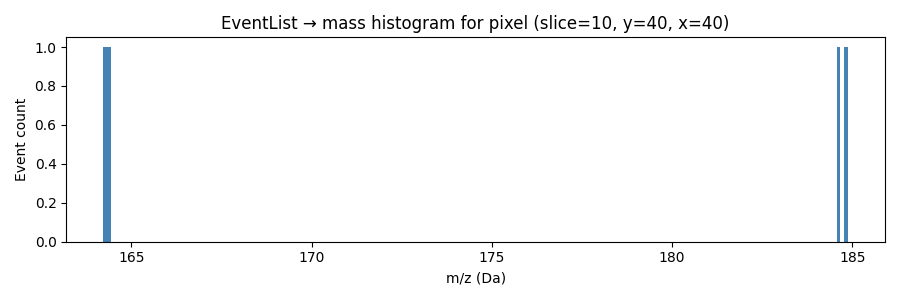

In [24]:
# An example of manually binning one pixel's EventList into a mass histogram

import h5py

with h5py.File(RAW, 'r') as f:
    mass_axis = np.asarray(f['FullSpectra/MassAxis'])

depth, y, x = 10, 40, 40
pixel_events = event_list.data[depth, y, x]
if hasattr(pixel_events, 'compute'):
    # if signal was lazy, compute it:
    pixel_events = pixel_events.compute()
events = np.asarray(pixel_events, dtype=int)
valid  = (events >= 0) & (events < len(mass_axis))
masses = mass_axis[events[valid]]

fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(masses, bins=200, color='steelblue')
ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Event count')
ax.set_title(f'EventList → mass histogram for pixel (slice={depth}, y={y}, x={x})')
fig.tight_layout()

---
## 4 Metadata

The Tofwerk data format contains a range of metadata that is loaded into any signal returned by the reader. Aside from metadata specific to particular signal types, all signals returned by the reader contain the same metadata that was present in the original file.

In [25]:
sum_s, nominal_peak_data, additional_peak_data, event_list, fib_images = hs.load(PREPROCESSED, file_format="Tofwerk", signal='all', lazy=True)

WARNING | RosettaSciIO | FIBImages: 1 image(s) skipped — shape differs from dominant (256, 256): Image1300 (254, 256) (rsciio.tofwerk._api:1410)


In [26]:
sum_s.metadata

├── Acquisition_instrument
│   └── FIB_SIMS
│       ├── DAQ
│       │   ├── computer_id = 2eee7326-6de0-4acc-8e3a-856442596288
│       │   ├── gui_version = 1.12.2.0
│       │   ├── hardware = Cronologic xTDC4
│       │   └── tofdaq_version = 1.990759
│       ├── FIB
│       │   ├── current_A = 1044.3125
│       │   ├── hardware = Tescan
│       │   ├── pixel_size_um = 0.15625
│       │   ├── view_field_mm = 0.02
│       │   └── voltage_kV = 30.0
│       ├── ToF
│       │   ├── ion_mode = positive
│       │   ├── mass_calib_mode = 0
│       │   ├── mass_calib_p1 = 812.2414830833737
│       │   ├── mass_calib_p2 = 222.0153330865752
│       │   ├── mass_range_Da = [1.0, 216.0]
│       │   ├── n_peaks = 217
│       │   ├── sample_interval_s = 8.333333467724913e-10
│       │   ├── single_ion_signal = 0.8333333730697632
│       │   └── tof_period_samples = 10450
│       ├── chamber_pressure_Pa = 0.0002386567396313364
│       ├── file_type = pre-processed
│       ├── n_depth_slices = 1301
│       └── n_segments = 128
├── General
│   ├── FileIO
│   │   └── 0
│   │       ├── hyperspy_version = 2.4.1.dev21+gcf49cd3fe
│   │       ├── io_plugin = rsciio.tofwerk
│   │       ├── operation = load
│   │       └── timestamp = 2026-04-28T21:37:55.462076-06:00
│   ├── date = 2023-05-15
│   ├── original_filename = pfib_1301x128x128_AlTiPt.h5
│   ├── time = 20:50:47
│   ├── time_zone = -04:00
│   └── title = pfib_1301x128x128_AlTiPt (sum spectrum)
└── Signal
    ├── peak_table <list>
    │   ╠══ [0]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 0.5
    │   ║   ╠══ mass = 1.0
    │   ║   ╚══ upper_integration_limit = 1.5
    │   ╠══ [1]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 1.5
    │   ║   ╠══ mass = 2.0
    │   ║   ╚══ upper_integration_limit = 2.5
    │   ╠══ [10]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 10.5
    │   ║   ╠══ mass = 11.0
    │   ║   ╚══ upper_integration_limit = 11.5
    │   ╠══ [100]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 100.5
    │   ║   ╠══ mass = 101.0
    │   ║   ╚══ upper_integration_limit = 101.5
    │   ╠══ [101]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 101.5
    │   ║   ╠══ mass = 102.0
    │   ║   ╚══ upper_integration_limit = 102.5
    │   ╠══ [102]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 102.5
    │   ║   ╠══ mass = 103.0
    │   ║   ╚══ upper_integration_limit = 103.5
    │   ╠══ [103]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 103.5
    │   ║   ╠══ mass = 104.0
    │   ║   ╚══ upper_integration_limit = 104.5
    │   ╠══ [104]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 104.5
    │   ║   ╠══ mass = 105.0
    │   ║   ╚══ upper_integration_limit = 105.5
    │   ╠══ [105]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 105.5
    │   ║   ╠══ mass = 106.0
    │   ║   ╚══ upper_integration_limit = 106.5
    │   ╠══ [106]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 106.5
    │   ║   ╠══ mass = 107.0
    │   ║   ╚══ upper_integration_limit = 107.5
    │   ╠══ [107]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 107.5
    │   ║   ╠══ mass = 108.0
    │   ║   ╚══ upper_integration_limit = 108.5
    │   ╠══ [108]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 108.5
    │   ║   ╠══ mass = 109.0
    │   ║   ╚══ upper_integration_limit = 109.5
    │   ╠══ [109]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 109.5
    │   ║   ╠══ mass = 110.0
    │   ║   ╚══ upper_integration_limit = 110.5
    │   ╠══ [11]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_limit = 11.5
    │   ║   ╠══ mass = 12.0
    │   ║   ╚══ upper_integration_limit = 12.5
    │   ╠══ [110]
    │   ║   ╠══ label = nominal
    │   ║   ╠══ lower_integration_l

In [27]:
# a selection of potentially interesting metadata, most of which is under the "FIB_SIMS" key
fib_meta = sum_s.metadata.Acquisition_instrument.FIB_SIMS
gen = sum_s.metadata.General
print(f'Date / time:      {gen.date}  {gen.time}  {gen.time_zone}')
print(f'FIB hardware:     {fib_meta.FIB.hardware}  @  {fib_meta.FIB.voltage_kV:.0f} kV')
print(f'Pixel size:       {fib_meta.FIB.pixel_size_um:.4f} µm')
print(f'Ion mode:         {fib_meta.ToF.ion_mode}')
print(f'DAQ:              {fib_meta.DAQ.hardware}  (TofDAQ {fib_meta.DAQ.tofdaq_version})')
print(f'File type:        {fib_meta.file_type}')
print(f'Depth slices:     {fib_meta.n_depth_slices}')
print(f'Peaks:            {fib_meta.ToF.n_peaks}')
print(f'Mass range:       {fib_meta.ToF.mass_range_Da} Da')
print(f'Data shape:       {peak_data.data.shape}  (depth, y, x, m/z)')

Date / time:      2023-05-15  20:50:47  -04:00
FIB hardware:     Tescan  @  30 kV
Pixel size:       0.1562 µm
Ion mode:         positive
DAQ:              Cronologic xTDC4  (TofDAQ 1.990759)
File type:        pre-processed
Depth slices:     1301
Peaks:            217
Mass range:       [1.0, 216.0] Da
Data shape:       (1301, 128, 128, 216)  (depth, y, x, m/z)


---
## 5 Peak table & reintegration

`PeakData/PeakTable` from the HDF5 file is stored in two places on every signal
that has peak data:

| Location | Purpose |
|---|---|
| `original_metadata.PeakTable` | Verbatim record of what was read from the file — do not modify |
| `metadata.Signal.peak_table` | Active list used for peak integration — safe to modify |

`FIBSIMSSpectrum.reintegrate_peaks(event_list_signal)` re-derives the full
`(depth, y, x, m/z)` array from raw TDC timestamps using the current (or a
user-supplied) peak table, without re-opening the `.h5` file.

In [28]:
import pandas as pd

[sum_spec, nominal_peak_data, additional_peak_data, event_list] = hs.load(
    PREPROCESSED,
    file_format='Tofwerk',
    signal=['sum_spectrum', 'nominal_peak_data', 'additional_peak_data', 'event_list'],
    lazy=True
)    

In [29]:
# in the example dataset, there is one manually-added peak at the end of the
# table representing 194Pt
nominal_peak_table = list(nominal_peak_data.metadata.Signal.peak_table)
additional_peak_table = list(additional_peak_data.metadata.Signal.peak_table)

print(f'{len(nominal_peak_table)} peaks in nominal metadata.Signal.peak_table')
print(f'{len(additional_peak_table)} peaks in additional metadata.Signal.peak_table')
print(f'{len(peak_data.original_metadata.PeakTable)} peaks in original_metadata.PeakTable  (sum of nominal + additional should match)\n')

nominal_df = pd.DataFrame(nominal_peak_table)
nominal_df['window_width'] = nominal_df['upper_integration_limit'] - nominal_df['lower_integration_limit']

additional_df = pd.DataFrame(additional_peak_table)
additional_df['window_width'] = additional_df['upper_integration_limit'] - additional_df['lower_integration_limit']

nominal_df, additional_df

216 peaks in nominal metadata.Signal.peak_table
1 peaks in additional metadata.Signal.peak_table
217 peaks in original_metadata.PeakTable  (sum of nominal + additional should match)



(       label   mass  lower_integration_limit  upper_integration_limit  \
 0    nominal    1.0                      0.5                      1.5   
 1    nominal    2.0                      1.5                      2.5   
 2    nominal    3.0                      2.5                      3.5   
 3    nominal    4.0                      3.5                      4.5   
 4    nominal    5.0                      4.5                      5.5   
 ..       ...    ...                      ...                      ...   
 211  nominal  212.0                    211.5                    212.5   
 212  nominal  213.0                    212.5                    213.5   
 213  nominal  214.0                    213.5                    214.5   
 214  nominal  215.0                    214.5                    215.5   
 215  nominal  216.0                    215.5                    216.5   
 
      window_width  
 0             1.0  
 1             1.0  
 2             1.0  
 3             1.0  
 4   

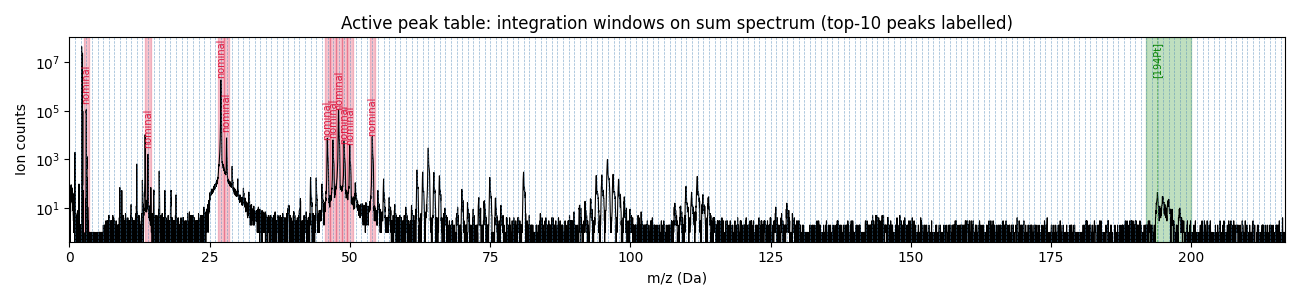

In [30]:
# Integration windows visualised on the sum spectrum.
# Each dashed line marks a peak's nominal mass; top-10 peaks by total count, plus the
# single manually integrated peak are shaded and labelled.

# Use the already-loaded sum_spec
mz = sum_spec.axes_manager.signal_axes[0].axis
sum_s_data = sum_spec.data.compute() if hasattr(sum_spec.data, 'compute') else np.asarray(sum_spec.data)

# Look up each peak's count in the sum spectrum by nearest-mass match
peak_counts_data = np.array([sum_s_data[np.argmin(np.abs(mz - p['mass']))] for p in nominal_peak_table])
top10_idx = np.argsort(peak_counts_data)[-10:]

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(mz, sum_s_data, 'k-', lw=0.8)
ax.set_yscale('log')
for p in nominal_peak_table:
    ax.axvline(p['mass'], color='steelblue', lw=0.5, ls='--', alpha=0.6)

# Shade and label the top-10 peaks
for idx in top10_idx:
    p = nominal_peak_table[idx]
    ax.axvspan(p['lower_integration_limit'], p['upper_integration_limit'],
               alpha=0.25, color='crimson')
    ax.annotate(p['label'], xy=(p['mass'], peak_counts_data[idx]),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=7, rotation=90, color='crimson')

# shade and label the additional peak(s)
for p in additional_peak_table:
    ax.axvline(p['mass'], color='green', lw=0.5, ls='--', alpha=0.6)
    ax.axvspan(p['lower_integration_limit'], p['upper_integration_limit'],
           alpha=0.25, color='green')
    ax.annotate(p['label'], xy=(p['mass'], peak_counts_data[idx]),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=7, rotation=90, color='green')


ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Ion counts')
ax.set_title('Active peak table: integration windows on sum spectrum (top-10 peaks labelled)')
ax.set_xlim(mz[0], mz[-1])
fig.tight_layout()

### 5.1 Modifying integration windows

`metadata.Signal.peak_table` is a plain Python list of dicts.  To reintegrate
with different windows, make a copy, edit the window bounds, then pass it to
`reintegrate_peaks` along with an EventList signal:

```python
s.reintegrate_peaks(event_list_signal, peak_table=modified_table)
```

The result is a new `FIBSIMSSpectrum` with recomputed data and an updated m/z axis.

In [31]:
# ── Load data including existing peak data and (more importantly) event_list ──────────────
[sum_spec, fib_sims, event_list_sig] = hs.load(
    PREPROCESSED,
    file_format='Tofwerk',
    signal=['sum_spectrum', 'nominal_peak_data', 'event_list'],
    lazy=True
)

In [32]:
# ── Calculate total number of ions detected (for later comparison) ───────────────────────
# (this should take less than a minute on the example dataset)
orig_total = float(fib_sims.data.sum())
print(f"Total ion count (original 216-peak table): {orig_total:,.0f}")

Total ion count (original 216-peak table): 44,843,688


In [33]:
# ── Build a focused, chemically-labelled peak table ──────────────────────────────────────
#
# AlTiPt sample — we care about:
#   Al:  27 Da  (100% natural abundance, dominant Al isotope)
#   Ti:  46, 47, 48, 49, 50 Da  (all five stable isotopes)
#   Pt:  194, 195, 196, 198 Da  (four most abundant Pt isotopes)
#
# Windows are ±0.3 Da — tight enough to exclude adjacent nominal peaks on the
# original 1 Da grid, broad enough to capture the full peak at this resolution.

SPECIES = [
    # (label,  mass_Da)
    ("27Al",   27.0),
    ("46Ti",   46.0),
    ("47Ti",   47.0),
    ("48Ti",   48.0),
    ("49Ti",   49.0),
    ("50Ti",   50.0),
    ("194Pt", 194.0),
    ("195Pt", 195.0),
    ("196Pt", 196.0),
    ("198Pt", 198.0),
]
HALF_WINDOW = 0.3

focused_table = [
    {
        "label": label,
        "mass": mass,
        "lower_integration_limit": mass - HALF_WINDOW,
        "upper_integration_limit": mass + HALF_WINDOW,
    }
    for label, mass in SPECIES
]

print("\nNew focused peak table:")
print(f"  {'Label':>6}  {'mass':>7}  {'window':>16}")
for p in focused_table:
    lo, hi = p["lower_integration_limit"], p["upper_integration_limit"]
    print(f"  {p['label']:>6}  {p['mass']:>6.1f} Da  [{lo:.1f}, {hi:.1f}]")


New focused peak table:
   Label     mass            window
    27Al    27.0 Da  [26.7, 27.3]
    46Ti    46.0 Da  [45.7, 46.3]
    47Ti    47.0 Da  [46.7, 47.3]
    48Ti    48.0 Da  [47.7, 48.3]
    49Ti    49.0 Da  [48.7, 49.3]
    50Ti    50.0 Da  [49.7, 50.3]
   194Pt   194.0 Da  [193.7, 194.3]
   195Pt   195.0 Da  [194.7, 195.3]
   196Pt   196.0 Da  [195.7, 196.3]
   198Pt   198.0 Da  [197.7, 198.3]


In [34]:
# event_list is the raw data source for reintegration — already loaded above.
print(event_list_sig)

<LazySignal, title: pfib_1301x128x128_AlTiPt (event list), dimensions: (128, 128, 1301|ragged)>


In [35]:
# ── Reintegrate ────────────────────────────────────────────────────────────

# reintegrate_peaks processes the full EventList

print(f"\nReintegrating {fib_sims.data.shape[0]} depth slices × "
      f"{fib_sims.data.shape[1]}×{fib_sims.data.shape[2]} pixels "
      f"→ {len(focused_table)} peaks…")
t0 = time.perf_counter()

# Pass peak_table=modified_table to use the widened windows.
fib_focused = fib_sims.reintegrate_peaks(event_list_sig, peak_table=focused_table)


elapsed = time.perf_counter() - t0
print(f"  done in {elapsed:.1f}s\n")

print(f"Reintegrated data shape: {fib_focused.data.shape}")
print(f"m/z axis labels: {[p['label'] for p in fib_focused.metadata.Signal.peak_table]}")
print(f"m/z axis values: {fib_focused.axes_manager.signal_axes[0].axis}")

focused_total = float(fib_focused.data.sum())
frac = focused_total / orig_total
print(f"\nTotal ion count (focused 10-peak table): {focused_total:,.0f}")
print(f"Fraction of all ions in Al/Ti/Pt windows: {frac:.4f}  ({frac*100:.2f}%)")


Reintegrating 1301 depth slices × 128×128 pixels → 10 peaks…
[########################################] | 100% Completed | 16.30 s


Reconstructing peak data:   0%|          | 0/1301 [00:00<?, ? slices/s]

  done in 22.8s

Reintegrated data shape: (1301, 128, 128, 10)
m/z axis labels: ['27Al', '46Ti', '47Ti', '48Ti', '49Ti', '50Ti', '194Pt', '195Pt', '196Pt', '198Pt']
m/z axis values: [ 27.  46.  47.  48.  49.  50. 194. 195. 196. 198.]

Total ion count (focused 10-peak table): 159,754
Fraction of all ions in Al/Ti/Pt windows: 0.0036  (0.36%)


In [36]:
# ── Per-element depth profiles ─────────────────────────────────────────────
# Sum over x and y to get a 1D depth profile per element.

print("\nPer-element depth profiles (ion counts summed over all pixels):")
print(f"  {'Depth':>7}  " + "  ".join(f"{p['label']:>7}" for p in focused_table))

# fib_focused.data shape: (depth, y, x, n_peaks)
depth_profiles = fib_focused.data.sum(axis=(1, 2))  # shape: (depth, n_peaks)

n_show = min(15, depth_profiles.shape[0])
for w in range(n_show):
    row = "  ".join(f"{depth_profiles[w, k]:>7.1f}" for k in range(len(SPECIES)))
    print(f"  {w:>7}  {row}")
if depth_profiles.shape[0] > n_show:
    print(f"  ... ({depth_profiles.shape[0] - n_show} more slices not shown)")


Per-element depth profiles (ion counts summed over all pixels):
    Depth     27Al     46Ti     47Ti     48Ti     49Ti     50Ti    194Pt    195Pt    196Pt    198Pt
        0  12678.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
        1  15066.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
        2  15303.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
        3  15473.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
        4  15103.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
        5  12747.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
        6   7766.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
        7   4198.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0
        8   2573.0      0.0      0.

In [37]:
# ── Element totals across the whole volume ─────────────────────────────────

print("\nTotal counts per element across entire acquisition:")
element_totals = depth_profiles.sum(axis=0)
for k, (label, _) in enumerate(SPECIES):
    pct = 100 * element_totals[k] / focused_total if focused_total > 0 else 0
    print(f"  {label:>6}:  {element_totals[k]:>10.0f}  ({pct:5.1f}% of focused total)")


Total counts per element across entire acquisition:
    27Al:      159642  ( 99.9% of focused total)
    46Ti:           0  (  0.0% of focused total)
    47Ti:           0  (  0.0% of focused total)
    48Ti:         112  (  0.1% of focused total)
    49Ti:           0  (  0.0% of focused total)
    50Ti:           0  (  0.0% of focused total)
   194Pt:           0  (  0.0% of focused total)
   195Pt:           0  (  0.0% of focused total)
   196Pt:           0  (  0.0% of focused total)
   198Pt:           0  (  0.0% of focused total)


## 6 Example Elemental Analysis

In [45]:
# ── Load pre-processed nominal peak data directly ──────────────────────────────
# The pre-processed file already has all 216 integer-mass peaks integrated;
# no EventList reintegration is needed here.
[sum_spec, s] = hs.load(
    PREPROCESSED,
    file_format="Tofwerk",
    signal=["sum_spectrum", "nominal_peak_data"],
    lazy=True,
)
data    = s.data   # lazy (depth, y, x, 216)
mz_axis = s.axes_manager.signal_axes[0].axis
n_depth, ny, nx, n_peaks = data.shape
print(s)
print(f"Data shape: {data.shape}  (depth, y, x, m/z)")

<LazyFIBSIMSSpectrum, title: pfib_1301x128x128_AlTiPt (nominal peak data), dimensions: (128, 128, 1301|216)>
Data shape: (1301, 128, 128, 216)  (depth, y, x, m/z)


In [46]:
# ── Select peaks by nearest-mass matching ─────────────────────────────────────
SPECIES = [
    ("27Al",   27.0),
    ("46Ti",   46.0), ("47Ti",  47.0), ("48Ti",  48.0), ("49Ti",  49.0), ("50Ti",  50.0),
    ("194Pt", 194.0), ("195Pt", 195.0), ("196Pt", 196.0), ("198Pt", 198.0),
]
labels       = [sp[0] for sp in SPECIES]
masses_req   = [sp[1] for sp in SPECIES]
peak_indices = [int(np.argmin(np.abs(mz_axis - m))) for m in masses_req]
idx          = {label: pi for label, pi in zip(labels, peak_indices)}

print("Matched peaks (requested → actual m/z):")
for label, mr, pi in zip(labels, masses_req, peak_indices):
    print(f"  {label:>6}: {mr:.1f} Da → {mz_axis[pi]:.3f} Da  (axis index {pi})")

# ── Depth profiles: sum over x and y for each selected peak ───────────────────
print("\nComputing depth profiles…")
profiles = data[:, :, :, peak_indices].sum(axis=(1, 2))
if hasattr(profiles, "compute"):
    profiles = profiles.compute()   # shape (n_depth, n_selected) (takes about a minute)
print(f"Done. Profiles shape: {profiles.shape}")

Matched peaks (requested → actual m/z):
    27Al: 27.0 Da → 27.000 Da  (axis index 26)
    46Ti: 46.0 Da → 46.000 Da  (axis index 45)
    47Ti: 47.0 Da → 47.000 Da  (axis index 46)
    48Ti: 48.0 Da → 48.000 Da  (axis index 47)
    49Ti: 49.0 Da → 49.000 Da  (axis index 48)
    50Ti: 50.0 Da → 50.000 Da  (axis index 49)
   194Pt: 194.0 Da → 194.000 Da  (axis index 193)
   195Pt: 195.0 Da → 195.000 Da  (axis index 194)
   196Pt: 196.0 Da → 196.000 Da  (axis index 195)
   198Pt: 198.0 Da → 198.000 Da  (axis index 197)

Computing depth profiles…
Done. Profiles shape: (1301, 10)


In [51]:
# ── Summed element channels ───────────────────────────────────────────────────
ti_labels = ["46Ti", "47Ti", "48Ti", "49Ti", "50Ti"]
pt_labels = ["194Pt", "195Pt", "196Pt", "198Pt"]

al_profile = profiles[:, labels.index("27Al")]
ti_profile = sum(profiles[:, labels.index(l)] for l in ti_labels)
pt_profile = sum(profiles[:, labels.index(l)] for l in pt_labels)

# ── Auto-detect layer peaks ────────────────────────────────────────────────────
# Ti has the clearest, most isolated peaks — use it as the cycle anchor.
# Pt and Al are then found as local maxima within a search window around each Ti peak,
# avoiding false detections (e.g. the Al surface cap at slice ~0).
from scipy.signal import find_peaks as _find_peaks

def find_layer_peaks(profile, n_cycles=3, min_distance=200):
    pks, _ = _find_peaks(profile, height=profile.max() * 0.1, distance=min_distance)
    if len(pks) >= n_cycles:
        top = np.argsort(profile[pks])[-n_cycles:]
        pks = np.sort(pks[top])
    return pks[:n_cycles].tolist()

TI_PEAKS = find_layer_peaks(ti_profile)
N_CYCLES  = len(TI_PEAKS)
SEARCH_WIN = 80   # slices to search around each Ti peak for co-located Pt and Al

PT_PEAKS, AL_PEAKS = [], []
for ti_c in TI_PEAKS:
    lo, hi = max(0, ti_c - SEARCH_WIN), min(n_depth, ti_c + SEARCH_WIN)
    PT_PEAKS.append(lo + int(pt_profile[lo:hi].argmax()))
    AL_PEAKS.append(lo + int(al_profile[lo:hi].argmax()))

MAP_HALF_WIN = 20

print("Layer peak positions (depth slices):")
print(f"  Ti: {TI_PEAKS}")
print(f"  Pt: {PT_PEAKS}")
print(f"  Al: {AL_PEAKS}")

Layer peak positions (depth slices):
  Ti: [357, 702, 1053]
  Pt: [363, 717, 1079]
  Al: [393, 739, 1059]


In [52]:
# ── Interlayer spacings ────────────────────────────────────────────────────────
print("\nInterlayer spacings (slices):")
print(f"  {'Cycle':>5}  {'Ti':>6}  {'Pt':>6}  {'Al':>6}  {'Ti→Pt':>6}  {'Pt→Al':>6}  {'Ti→Al':>6}")
for c in range(N_CYCLES):
    ti_pt = PT_PEAKS[c] - TI_PEAKS[c]
    pt_al = AL_PEAKS[c] - PT_PEAKS[c]
    ti_al = AL_PEAKS[c] - TI_PEAKS[c]
    print(f"  {c+1:>5}  {TI_PEAKS[c]:>6}  {PT_PEAKS[c]:>6}  {AL_PEAKS[c]:>6}"
          f"  {ti_pt:>6}  {pt_al:>6}  {ti_al:>6}")

if N_CYCLES > 1:
    periods_ti = [TI_PEAKS[i + 1] - TI_PEAKS[i] for i in range(N_CYCLES - 1)]
    periods_al = [AL_PEAKS[i + 1] - AL_PEAKS[i] for i in range(N_CYCLES - 1)]
    print(f"\nCycle period — Ti: {periods_ti} (mean {np.mean(periods_ti):.0f} slices)")
    print(f"Cycle period — Al: {periods_al} (mean {np.mean(periods_al):.0f} slices)")


Interlayer spacings (slices):
  Cycle      Ti      Pt      Al   Ti→Pt   Pt→Al   Ti→Al
      1     357     363     393       6      30      36
      2     702     717     739      15      22      37
      3    1053    1079    1059      26     -20       6

Cycle period — Ti: [345, 351] (mean 348 slices)
Cycle period — Al: [346, 320] (mean 333 slices)


Saved fig1_depth_profiles.png


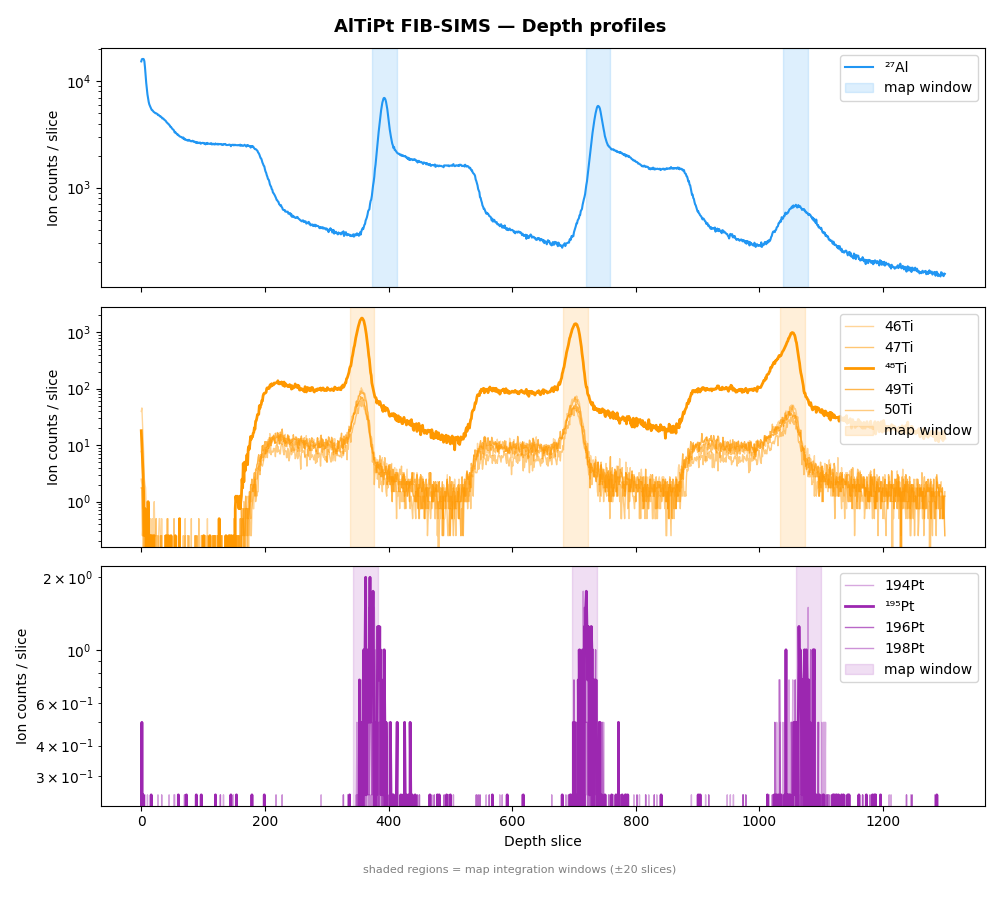

In [53]:
# ── Depth profiles for all three elements ─────────────────────────────────────
depths  = np.arange(n_depth)
COLOURS = {"Al": "#2196F3", "Ti": "#FF9800", "Pt": "#9C27B0"}

def add_map_windows(ax, peaks, colour):
    for i, centre in enumerate(peaks):
        ax.axvspan(centre - MAP_HALF_WIN, centre + MAP_HALF_WIN,
                   color=colour, alpha=0.15,
                   label="map window" if i == 0 else None)

fig1, (ax_al, ax_ti, ax_pt) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
fig1.suptitle("AlTiPt FIB-SIMS — Depth profiles", fontsize=13, fontweight="bold")

ax_al.plot(depths, al_profile, color=COLOURS["Al"], lw=1.5, label="²⁷Al")
add_map_windows(ax_al, AL_PEAKS[:N_CYCLES], COLOURS["Al"])
ax_al.set_ylabel("Ion counts / slice")
ax_al.legend(loc="upper right")
ax_al.set_yscale("log")

TI_ALPHAS = {"46Ti": 0.4, "47Ti": 0.55, "48Ti": 1.0, "49Ti": 0.7, "50Ti": 0.5}
for l in ti_labels:
    lw = 2.0 if l == "48Ti" else 1.0
    ax_ti.plot(depths, profiles[:, labels.index(l)],
               color=COLOURS["Ti"], alpha=TI_ALPHAS[l], lw=lw,
               label="⁴⁸Ti" if l == "48Ti" else l)
add_map_windows(ax_ti, TI_PEAKS[:N_CYCLES], COLOURS["Ti"])
ax_ti.set_ylabel("Ion counts / slice")
ax_ti.legend(loc="upper right")
ax_ti.set_yscale("log")

PT_ALPHAS = {"194Pt": 0.4, "195Pt": 1.0, "196Pt": 0.7, "198Pt": 0.5}
for l in pt_labels:
    lw = 2.0 if l == "195Pt" else 1.0
    ax_pt.plot(depths, profiles[:, labels.index(l)],
               color=COLOURS["Pt"], alpha=PT_ALPHAS[l], lw=lw,
               label="¹⁹⁵Pt" if l == "195Pt" else l)
add_map_windows(ax_pt, PT_PEAKS[:N_CYCLES], COLOURS["Pt"])
ax_pt.set_xlabel("Depth slice")
ax_pt.set_ylabel("Ion counts / slice")
ax_pt.legend(loc="upper right")
ax_pt.set_yscale("log")

fig1.text(0.52, 0.03, "shaded regions = map integration windows (±20 slices)",
          ha="center", fontsize=8, color="gray")
fig1.tight_layout(rect=[0, 0.04, 1, 1])
fig1.savefig("fig1_depth_profiles.png", dpi=150)
print("Saved fig1_depth_profiles.png")

/var/folders/tg/fqy_ylrd2hqg48t93zd804zc0000gn/T/ipykernel_4652/170100570.py:23: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig2, axes = plt.subplots(len(ELEMENTS), N_CYCLES,


Saved fig2_elemental_maps.png


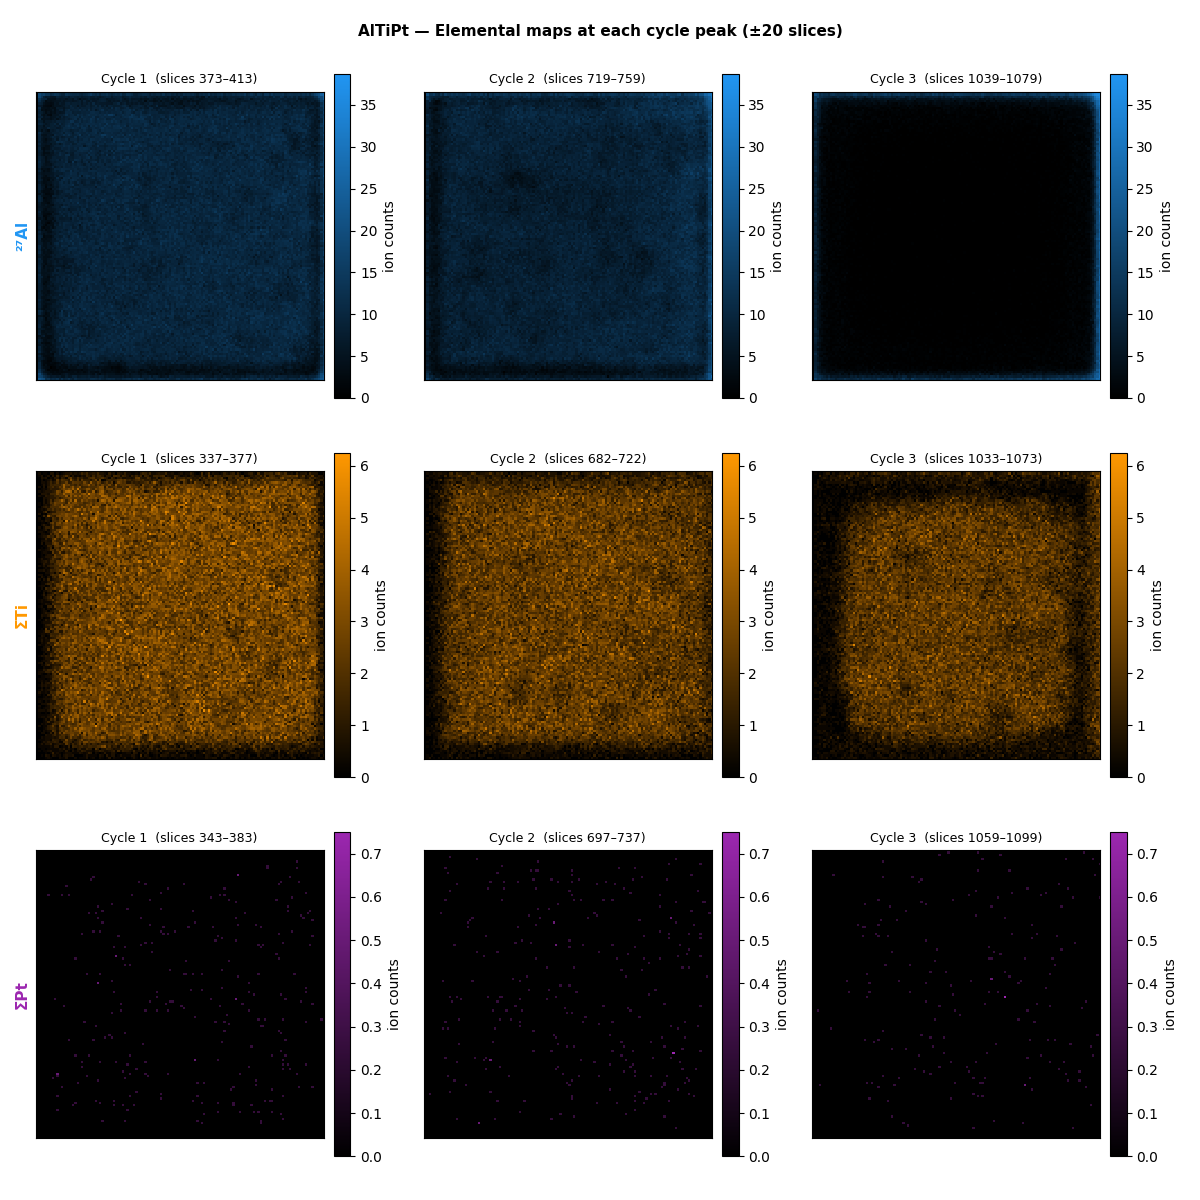

In [54]:
# ── Elemental maps windowed around each detected layer peak ────────────────────
# sel_indices must be indices into the full 216-peak m/z axis (use idx, not labels.index)
ti_sel = [idx[l] for l in ti_labels]
pt_sel = [idx[l] for l in pt_labels]
al_sel = [idx["27Al"]]

cmap_al = mcolors.LinearSegmentedColormap.from_list("al", ["#000000", "#2196F3"])
cmap_ti = mcolors.LinearSegmentedColormap.from_list("ti", ["#000000", "#FF9800"])
cmap_pt = mcolors.LinearSegmentedColormap.from_list("pt", ["#000000", "#9C27B0"])

def windowed_map(centre, sel_indices):
    lo    = max(0, centre - MAP_HALF_WIN)
    hi    = min(n_depth, centre + MAP_HALF_WIN + 1)
    chunk = data[lo:hi, :, :, :][:, :, :, sel_indices].sum(axis=(0, -1))
    return chunk.compute() if hasattr(chunk, "compute") else np.asarray(chunk)

ELEMENTS = [
    ("²⁷Al", al_sel, AL_PEAKS[:N_CYCLES], cmap_al, "#2196F3"),
    ("ΣTi",  ti_sel, TI_PEAKS[:N_CYCLES], cmap_ti, "#FF9800"),
    ("ΣPt",  pt_sel, PT_PEAKS[:N_CYCLES], cmap_pt, "#9C27B0"),
]

fig2, axes = plt.subplots(len(ELEMENTS), N_CYCLES,
                          figsize=(4 * N_CYCLES, 4 * len(ELEMENTS)))
fig2.suptitle(
    f"AlTiPt — Elemental maps at each cycle peak (±{MAP_HALF_WIN} slices)",
    fontsize=11, fontweight="bold",
)

for row, (label, sel_indices, centres, cmap, colour) in enumerate(ELEMENTS):
    maps = [windowed_map(c, sel_indices) for c in centres]
    vmax = max(float(m.max()) for m in maps)
    vmax = vmax if vmax > 0 else 1

    for col, (m, centre) in enumerate(zip(maps, centres)):
        ax  = axes[row, col]
        lo  = max(0, centre - MAP_HALF_WIN)
        hi  = min(n_depth, centre + MAP_HALF_WIN)
        im  = ax.imshow(m, cmap=cmap, vmin=0, vmax=vmax,
                        aspect="equal", interpolation="nearest")
        plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03, label="ion counts")
        ax.set_title(f"Cycle {col + 1}  (slices {lo}–{hi})", fontsize=9)
        if col == 0:
            ax.set_ylabel(label, fontsize=11, fontweight="bold", color=colour)
        ax.set_xticks([])
        ax.set_yticks([])

fig2.tight_layout()
fig2.savefig("fig2_elemental_maps.png", dpi=150)
print("Saved fig2_elemental_maps.png")


Ti isotope fractions (measured vs natural abundance):
   Isotope    Measured %    Natural %         Δ
      46Ti         5.99%        8.25%    -2.26%
      47Ti         5.50%        7.44%    -1.94%
      48Ti        79.51%       73.72%    +5.79%
      49Ti         5.33%        5.41%    -0.08%
      50Ti         3.66%        5.18%    -1.52%
Saved fig3_ti_isotope_ratios.png


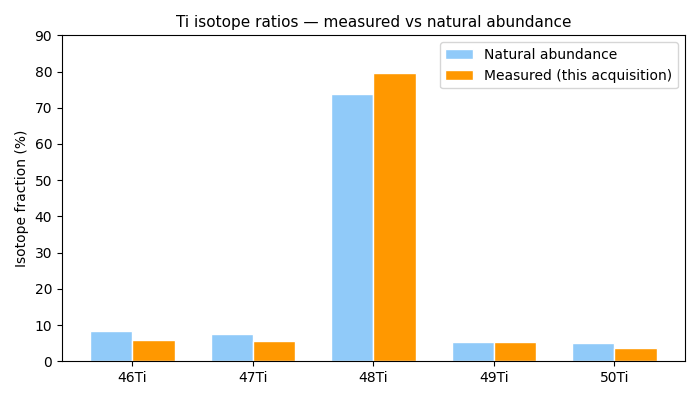

In [55]:
# ── Ti isotope ratios ──────────────────────────────────────────────────────────
#  Natural Ti isotope abundances:
#    Meija, J. et al. (2016) "Isotopic compositions of the elements 2013",
#    Pure and Applied Chemistry, 88(3), 265–291. https://doi.org/10.1515/pac-2015-0503

TI_NATURAL = {
    "46Ti": 8.25, "47Ti": 7.44, "48Ti": 73.72, "49Ti": 5.41, "50Ti": 5.18,
}

ti_totals   = {l: float(profiles[:, labels.index(l)].sum()) for l in ti_labels}
ti_sum      = sum(ti_totals.values())
ti_measured = {l: 100 * ti_totals[l] / ti_sum if ti_sum > 0 else 0 for l in ti_labels}

print("\nTi isotope fractions (measured vs natural abundance):")
print(f"  {'Isotope':>8}  {'Measured %':>12}  {'Natural %':>11}  {'Δ':>8}")
for l in ti_labels:
    meas = ti_measured[l]
    nat  = TI_NATURAL[l]
    print(f"  {l:>8}  {meas:>11.2f}%  {nat:>10.2f}%  {meas - nat:>+7.2f}%")

x     = np.arange(len(ti_labels))
width = 0.35

fig3, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, [TI_NATURAL[l]  for l in ti_labels], width,
       label="Natural abundance", color="#90CAF9", edgecolor="white")
ax.bar(x + width/2, [ti_measured[l] for l in ti_labels], width,
       label="Measured (this acquisition)", color="#FF9800", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(ti_labels)
ax.set_ylabel("Isotope fraction (%)")
ax.set_title("Ti isotope ratios — measured vs natural abundance", fontsize=11)
ax.legend()
ax.set_ylim(0, 90)
fig3.tight_layout()
fig3.savefig("fig3_ti_isotope_ratios.png", dpi=150)
print("Saved fig3_ti_isotope_ratios.png")